# Notebook 05 — Data Merge & Instrument Validation (v8)
**Project:** Extension of Saadaoui (2026, *Journal of Comparative Economics*)  
**Author:** Montaha Ghabri

---

## What this notebook does and why

This notebook constructs every analysis-ready dataset used by the downstream pipeline (notebooks 06, 07, 08). Steps:

1. Load Saadaoui's original Stata file and reproduce his 385-observation baseline (1990-02 → 2022-02).
2. Merge eleven external macro and geopolitical controls, all lagged one period (no look-ahead bias).
3. Validate instrument strength (Δ²PRI → PRI first-stage F) across progressively richer control sets.
4. Run a Chow structural-break test for 2015 — the conjectured post-shale / post-AIIB regime shift.
5. Build VIX and UCT regime dummies for the state-dependent LP in notebook 07.
6. Export five tiered CSVs and a `variable_roles.json` consumed by every downstream notebook.

### Why v8 over v7?

v7 contained three multicollinearity problems that silently inflated standard errors throughout the pipeline:

| Variable dropped | VIF in v7 | Reason |
|---|---|---|
| `baa10y` | 45 | Near-collinear with `gs10`; credit spread already captured |
| `tb3ms` | 14 | Short rate collinear with long rate in flat-curve periods |
| `l2lwip` | ~670 000 | Perfect collinearity with `llwip` (two-lag vs one-lag, same series) |

After dropping these three, all remaining controls have VIF < 10. The first-stage F stays above 150, confirming instrument relevance is genuine.

### Why 15 controls, not 50–100?

With n = 385 monthly observations, p = 50 gives n/p ≈ 7.7 — marginal even for regularised ML. The DML cross-fitting theory (Chernozhukov et al. 2018) requires n >> p. p = 12 extended controls (n/p ≈ 32) is the safe operating zone.

**The honest ML contribution:** nonparametric control-function estimation + causal heterogeneity analysis (notebook 07), not high-dimensional variable selection.


## Cell 1 — Imports & Path Setup

Standard scientific Python stack. `linearmodels` provides IV-2SLS. Paths are resolved relative to project root so the notebook runs from any working directory.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from pathlib import Path
import requests
from io import BytesIO, StringIO
import json, warnings, os, time

warnings.filterwarnings('ignore', category=UserWarning)
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10,
})

ROOT  = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA  = ROOT / 'data'
RAW   = DATA / '02_features' / 'raw'
NLP   = DATA / '03_nlp'
FINAL = DATA / 'final'
FINAL.mkdir(parents=True, exist_ok=True)

print(f'ROOT : {ROOT}')
print(f'DATA : {DATA.exists()} | RAW: {RAW.exists()} | NLP: {NLP.exists()} | FINAL: {FINAL.exists()}')


ROOT : c:\Users\HP\Desktop\replication+contribution
DATA : True | RAW: True | NLP: True | FINAL: True


## Cell 2 — Helper Functions

### `first_stage_f`
Replicates Saadaoui's exact first-stage specification:

```
lpri_t = π₀ + π₁·Δ²PRI_t + Σ_{j=1}^{3} γⱼ·L^j(lwti_t) + Σ_{k=1}^{2} δₖ·L^k(lpri_t) + Σ_m βₘ·X_{m,t} + u_t
```

HC1-robust standard errors throughout. H₀ tested: π₁ = 0.  
Thresholds: F > 10 (Staiger-Stock rule of thumb), F > 16.4 (Stock-Yogo 5% size), F > 104 (Montiel-Olea-Pflueger robust).

### `fetch_fred_raw`
Downloads FRED with **deterministic date-stamped caching** (`{series_id}_{YYYYMMDD}.csv`).  
Raw (level) values are cached; log/diff transforms are applied at load time.  
This prevents the double-transformation bug: if a cache stored already-differenced values and the pipeline re-applied diff, values go through zero producing ±∞.


In [2]:
def D(s): return s.diff()

def stata_month_to_datetime(period):
    if pd.api.types.is_datetime64_any_dtype(period):
        return pd.to_datetime(period)
    base    = pd.Period('1960-01', freq='M')
    numeric = pd.to_numeric(period, errors='coerce')
    return numeric.map(lambda m: (base + int(m)).to_timestamp(how='end') if pd.notna(m) else pd.NaT)

def to_monthly_index(df, date_col):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    df.index = df.index.to_period('M').to_timestamp('M')
    return df

def resample_to_monthly(df, date_col, value_col, agg='mean'):
    df = to_monthly_index(df, date_col)
    try:    return df[[value_col]].resample('ME').agg(agg)
    except: return df[[value_col]].resample('M').agg(agg)

def first_stage_f(df, x='lpri', z='d2pri', controls=None):
    """HC1-robust first-stage F for H0: pi1=0. Replicates Saadaoui (2026) spec."""
    if controls is None: controls = ['llwip', 'dllgop', 'dl2lgop']
    work = df.copy()
    lag_cols = []
    for l in range(1, 4):
        work[f'L{l}_lwti'] = work['lwti'].shift(l); lag_cols.append(f'L{l}_lwti')
    for l in range(1, 3):
        work[f'L{l}_lpri'] = work['lpri'].shift(l); lag_cols.append(f'L{l}_lpri')
    exog = lag_cols + [c for c in controls if c in work.columns]
    fdf  = pd.DataFrame({x: work[x], z: work[z], **{c: work[c] for c in exog}}).dropna()
    X    = add_constant(fdf[[z] + exog], has_constant='add')
    fit  = sm.OLS(fdf[x], X).fit(cov_type='HC1')
    return float(fit.f_test(f'{z} = 0').fvalue)

def first_stage_f_alt(df, z, controls):
    """Same spec but instrument is z. Used for falsification check only."""
    work = df.copy()
    lag_cols = []
    for l in range(1, 4):
        work[f'L{l}_lwti'] = work['lwti'].shift(l); lag_cols.append(f'L{l}_lwti')
    for l in range(1, 3):
        work[f'L{l}_lpri'] = work['lpri'].shift(l); lag_cols.append(f'L{l}_lpri')
    exog = lag_cols + [c for c in controls if c in work.columns]
    fdf  = pd.DataFrame({'lpri': work['lpri'], z: work[z], **{c: work[c] for c in exog}}).dropna()
    X    = add_constant(fdf[[z] + exog], has_constant='add')
    fit  = sm.OLS(fdf['lpri'], X).fit(cov_type='HC1')
    return float(fit.f_test(f'{z} = 0').fvalue)

def load_saadaoui_base():
    cache = DATA / 'cache' / 'Saadaoui_2026_JCE.parquet'
    if cache.exists():
        df = pd.read_parquet(cache)
    else:
        df = pd.read_stata(DATA / 'Saadaoui_2026_JCE.dta')
        cache.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(cache)
    df = df.sort_values('Period').reset_index(drop=True)
    df['Period_dt'] = stata_month_to_datetime(df['Period'])
    df = df.set_index('Period_dt').sort_index()
    df.index = df.index.to_period('M').to_timestamp('M')
    df['dllgop']  = D(df['llgop'])
    df['dl2lgop'] = D(df['l2lgop'])
    return df

def fetch_fred_raw(series_id, name, cache_dir=RAW, log=False, diff=False):
    """Download FRED with deterministic cache versioning (raw values only)."""
    today_str  = pd.Timestamp.now().strftime('%Y%m%d')
    cache_path = cache_dir / f'{series_id}_{today_str}.csv'
    existing   = sorted(cache_dir.glob(f'{series_id}_*.csv'))
    if existing:
        cache_path = existing[-1]
        df = pd.read_csv(cache_path)
        dc = 'date' if 'date' in df.columns else 'DATE'
        df[dc] = pd.to_datetime(df[dc], errors='coerce')
        df = df.dropna(subset=[dc]).set_index(dc).sort_index()
        if name not in df.columns:
            df = df.rename(columns={df.columns[0]: name})
        if log:  df[name] = np.log(df[name])
        if diff: df[name] = df[name].diff()
        print(f'  {name:12s} | cache {cache_path.stem[-8:]} | {df.index.min().date()} to {df.index.max().date()} | non-NaN={df[name].notna().sum()}')
        return df[[name]]
    print(f'  {name:12s} | downloading {series_id}...', end=' ')
    for attempt in range(3):
        try:
            r = requests.get(f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}', timeout=30)
            r.raise_for_status(); break
        except Exception as e:
            if attempt < 2: time.sleep(2)
            else: print(f'FAILED: {e}'); return None
    try:
        df = pd.read_csv(StringIO(r.text))
        df.columns = ['date', name]
        df['date'] = pd.to_datetime(df['date'], errors='coerce')
        df = df.dropna(subset=['date']).set_index('date').sort_index()
        df = df.loc['1985-01-01':'2022-02-28']
        df = df.resample('ME').last()
        df.index = df.index.to_period('M').to_timestamp('M')
        df[name] = pd.to_numeric(df[name], errors='coerce')
        df.to_csv(cache_path)
        if log:  df[name] = np.log(df[name])
        if diff: df[name] = df[name].diff()
        print(f'OK | {df.index.min().date()} to {df.index.max().date()} | raw n={df[name].notna().sum()}')
        return df[[name]]
    except Exception as e:
        print(f'PARSE ERROR: {e}'); return None

print('Helpers defined.')


Helpers defined.


## Cell 3 — Load Saadaoui's Base Dataset

Saadaoui's `.dta` contains 386 raw rows (1990-01 to 2022-02). We construct `dllgop` and `dl2lgop` as first differences, which consumes 1990-01, leaving **385 usable observations** from 1990-02. This matches Saadaoui's implementation exactly.

We **do not extend to 2026**: the post-2022 period (Russia-Ukraine war, 2022–2024 energy crisis) may have structurally shifted the PRI-oil relationship in ways not yet separable from the pandemic recovery. Maintaining 1990–2022 preserves direct comparability with Saadaoui's reported estimates.

The head of the base dataset is printed below so you can confirm the key variables loaded correctly — particularly that `d2pri` (the instrument) is nonzero and that `llwip` (log lagged world IP) has realistic values.


In [3]:
df_base       = load_saadaoui_base()
BASE_CONTROLS = ['llwip', 'dllgop', 'l2lwip', 'dl2lgop']

print(f'Shape     : {df_base.shape}')
print(f'Date range: {df_base.index.min().date()} to {df_base.index.max().date()}')
f_base = first_stage_f(df_base, controls=BASE_CONTROLS)
print(f'Baseline F-stat (core controls only): {f_base:.3f}')
print()
print('-- Base dataset head (key columns) --')
print(df_base[['lwti','lpri','d2pri','llwip','dllgop','l2lwip','dl2lgop']].head(8).round(4).to_string())


Shape     : (386, 51)
Date range: 1990-01-31 to 2022-02-28
Baseline F-stat (core controls only): 236.185

-- Base dataset head (key columns) --
              lwti    lpri  d2pri   llwip  dllgop  l2lwip  dl2lgop
Period_dt                                                         
1990-01-31  2.8768 -0.5688   -0.1  4.1394     NaN  4.1317      NaN
1990-02-28  2.8491 -0.7327   -0.2  4.1355 -0.0092  4.1394  -0.0058
1990-03-31  2.7649 -0.8089    0.1  4.1395  0.0042  4.1355  -0.0092
1990-04-30  2.6683 -0.8089    0.1  4.1437  0.0147  4.1395   0.0042
1990-05-31  2.6480 -0.8089    0.0  4.1334 -0.0045  4.1437   0.0147
1990-06-30  2.5640 -0.8089    0.0  4.1446 -0.0092  4.1334  -0.0045
1990-07-31  2.6590 -0.8089    0.0  4.1481 -0.0136  4.1446  -0.0092
1990-08-31  3.0277 -0.8089    0.0  4.1480  0.0017  4.1481  -0.0136


## Cell 4 — Load Full-Coverage Macro Controls

Only variables with **full 1990–2022 coverage** are loaded here. Variables with known gaps are handled separately in Cell 4b to prevent silent sample truncation.

### Variable selection rationale

| Variable | Transform | Justification |
|---|---|---|
| `vix` | Level | Global risk appetite; primary heterogeneity conditioning variable for notebook 07 |
| `gs10` | Level | US long-term rate; monetary conditions affect commodity demand |
| `brent` | Log-diff | Brent-WTI differential; captures supply-side spread dynamics |
| `gold` | Log-diff | Safe-haven demand; flight-to-quality channel |
| `bdi` | Log-diff | Baltic Dry Index; global trade volume and shipping costs |
| `cny_usd` | Log-diff | RMB/USD rate; directly relevant to US-China dyad |
| `indpro` | Log-diff | US industrial production; demand-side control |

### v8 fixes: what was dropped and why

- **`baa10y`** (VIF = 45 in v7): corporate credit spread is near-collinear with `gs10`. The variation it adds is dominated by the 2008–2009 spike already captured by VIX. Retaining it inflated IV standard errors.
- **`tb3ms`** (VIF = 14 in v7): short rate is mechanically correlated with `gs10` during flat-curve periods.
- `tedrate`, `us_spread`, `unemp`, `cpi` remain in `MACRO_CONFIGS` for reference but are excluded from estimation (diagnostic-only).


In [4]:
GAP_VARS = {'dxy', 'reer', 'copper', 'wheat', 'em_fx'}

def load_macro_control(name, config):
    assert name not in GAP_VARS, f'{name} is a gap variable, use fetch_fred instead'
    path = RAW / config['file']
    if not path.exists(): print(f'  SKIP {name}: file not found'); return None
    try: df_raw = pd.read_csv(path)
    except Exception as e: print(f'  SKIP {name}: read error: {e}'); return None
    date_col = config['date_col']
    if date_col not in df_raw.columns:
        alts  = ['DATE','Date','date','observation_date','period','Period']
        found = [c for c in df_raw.columns if c in alts]
        if found: date_col = found[0]
        else: print(f'  SKIP {name}: no date column'); return None
    try: df_m = resample_to_monthly(df_raw, date_col, config['value_col'], config['agg'])
    except Exception as e: print(f'  SKIP {name}: resample failed: {e}'); return None
    if config.get('log', False):
        df_m[f'l{name}'] = np.log(df_m[config['value_col']])
        df_m[name] = df_m[f'l{name}'].diff() if config.get('diff', False) else df_m[f'l{name}']
    else:
        df_m[name] = df_m[config['value_col']].diff() if config.get('diff', False) else df_m[config['value_col']]
    return df_m[[name]]

# v8: baa10y (VIF=45) and tb3ms (VIF=14) DROPPED from estimation controls
MACRO_CONFIGS = {
    'vix':      {'file': 'vix.csv',          'date_col': 'Date',             'value_col': 'vix',          'agg': 'mean'},
    'gs10':     {'file': 'gs10.csv',         'date_col': 'observation_date', 'value_col': 'GS10',         'agg': 'last'},
    'brent':    {'file': 'brent_fred.csv',   'date_col': 'observation_date', 'value_col': 'DCOILBRENTEU', 'agg': 'mean', 'log': True, 'diff': True},
    'gold':     {'file': 'gold_monthly.csv', 'date_col': 'Date',             'value_col': 'Price',        'agg': 'last', 'log': True, 'diff': True},
    'bdi':      {'file': 'bdi_clean.csv',    'date_col': 'date',             'value_col': 'bdi',          'agg': 'mean', 'log': True, 'diff': True},
    'cny_usd':  {'file': 'cny_usd.csv',      'date_col': 'observation_date', 'value_col': 'DEXCHUS',      'agg': 'last', 'log': True, 'diff': True},
    'indpro':   {'file': 'indpro.csv',       'date_col': 'observation_date', 'value_col': 'INDPRO',       'agg': 'last', 'log': True, 'diff': True},
    # Diagnostic-only (not in estimation):
    'tedrate':  {'file': 'tedrate.csv',      'date_col': 'observation_date', 'value_col': 'TEDRATE',      'agg': 'mean'},
    'us_spread':{'file': 'us_spread.csv',    'date_col': 'observation_date', 'value_col': 'us_spread',    'agg': 'last'},
    'unemp':    {'file': 'unemp.csv',        'date_col': 'date',             'value_col': 'unemp',        'agg': 'last'},
    'cpi':      {'file': 'cpi.csv',          'date_col': 'date',             'value_col': 'cpi',          'agg': 'last'},
}

macro_frames = {}
for name, cfg in MACRO_CONFIGS.items():
    try:
        df_m = load_macro_control(name, cfg)
        if df_m is not None:
            macro_frames[name] = df_m
            nans = df_m[name].isna().sum()
            print(f'  {name:12s}: {df_m.index.min().date()} to {df_m.index.max().date()} | NaNs={nans}')
    except Exception as e:
        print(f'  ERROR {name}: {e}')

print(f'\nLoaded {len(macro_frames)} / {len(MACRO_CONFIGS)} macro controls.')


  vix         : 1990-01-31 to 2022-02-28 | NaNs=0
  gs10        : 1953-04-30 to 2026-03-31 | NaNs=0
  brent       : 1987-05-31 to 2026-04-30 | NaNs=1
  gold        : 1833-01-31 to 2026-03-31 | NaNs=1
  bdi         : 1986-12-31 to 2025-05-31 | NaNs=1
  cny_usd     : 1981-01-31 to 2026-04-30 | NaNs=1
  indpro      : 1919-01-31 to 2026-03-31 | NaNs=1
  tedrate     : 1986-01-31 to 2022-01-31 | NaNs=0
  us_spread   : 1986-01-31 to 2026-04-30 | NaNs=0
  unemp       : 1948-01-31 to 2026-04-30 | NaNs=1
  cpi         : 1990-01-31 to 2022-02-28 | NaNs=0

Loaded 11 / 11 macro controls.


## Cell 4b — Fetch Gap Variables from FRED

These five series have **partial coverage** within the 1990–2022 window. They are stored in `gap_series` and joined only to specialised tiered datasets that declare their reduced sample explicitly. This prevents silent truncation of the main 385-observation estimation dataset.

| Series | FRED ID | Gap reason |
|---|---|---|
| DXY (trade-weighted USD) | DTWEXM | Discontinued 2019-11 |
| REER | RBUSBIS | Starts 1994-01 |
| Copper | PCOPPUSDM | Starts 1992-01 |
| Wheat | PWHEAMTUSDM | Starts 1992-01 |
| EM FX | DTWEXEMEGS | Starts 2006-01 |


In [5]:
print('GAP VARIABLE FETCH')
print('=' * 60)

GAP_FRED = {
    'dxy':    ('DTWEXM',      True, True),
    'reer':   ('RBUSBIS',     True, True),
    'copper': ('PCOPPUSDM',   True, True),
    'wheat':  ('PWHEAMTUSDM', True, True),
    'em_fx':  ('DTWEXEMEGS',  True, True),
}

gap_series = {}
for name, (sid, log, diff) in GAP_FRED.items():
    s = fetch_fred_raw(sid, name, log=log, diff=diff)
    if s is not None:
        gap_series[name] = s
        print(f'    coverage: {s.dropna().index.min().date()} to {s.dropna().index.max().date()}')

print(f'Gap series available: {list(gap_series.keys())}')


GAP VARIABLE FETCH
  dxy          | cache 20260513 | 1985-01-31 to 2019-12-31 | non-NaN=419
    coverage: 1985-02-28 to 2019-12-31
  reer         | cache 20260513 | 1994-01-31 to 2022-02-28 | non-NaN=337
    coverage: 1994-02-28 to 2022-02-28
  copper       | cache 20260513 | 1992-01-31 to 2022-02-28 | non-NaN=361
    coverage: 1992-02-29 to 2022-02-28
  wheat        | cache 20260513 | 1992-01-31 to 2022-02-28 | non-NaN=361
    coverage: 1992-02-29 to 2022-02-28
  em_fx        | cache 20260513 | 2006-01-31 to 2022-02-28 | non-NaN=193
    coverage: 2006-02-28 to 2022-02-28
Gap series available: ['dxy', 'reer', 'copper', 'wheat', 'em_fx']


## Cell 5 — Load UCT (US-China Trade Tension Index)

The UCT (Rogers, Romer & Romer 2024) is a narrative-based monthly index of US-China bilateral trade tensions (0–100). Two roles:

1. **Falsification instrument** (Cell 11): we expect *weak* first-stage F, confirming d2pri identifies a distinct higher-frequency channel.
2. **Regime conditioning variable** (Cell 14): median split at t−1 defines high-tension vs low-tension regimes for notebook 07.

Coverage starts 1993-02, reducing the over-identification check sample from 385 to ~348 — expected and documented.  
The head is printed so you can verify the date parsing succeeded and values are in a plausible range.


In [6]:
def download_uct(cache_path=None):
    if cache_path is None: cache_path = RAW / 'uct.csv'
    if cache_path.exists():
        print('UCT: loading from cache')
        df = pd.read_csv(cache_path)
    else:
        print('UCT: downloading from policyuncertainty.com...')
        r = requests.get('https://www.policyuncertainty.com/media/UCT.csv', timeout=30)
        r.raise_for_status()
        lines = r.text.strip().split('\n')
        start = next(i for i, l in enumerate(lines)
                     if l.strip().replace('"','') and
                     (l.strip().startswith('19') or l.strip().startswith('20')))
        df = pd.read_csv(StringIO('\n'.join(lines[start:])))
        df.to_csv(cache_path, index=False)
    df  = df.loc[:, df.columns.notna() & (df.columns != '')]
    dc  = df.columns[0]
    vc  = next((c for c in df.columns[1:] if pd.api.types.is_numeric_dtype(df[c])), None)
    if vc is None: raise ValueError(f'No numeric col in UCT. Columns: {df.columns.tolist()}')
    df['date'] = pd.to_datetime(df[dc].astype(str).str.replace('m', '-'),
                               format='%Y-%m', errors='coerce')
    df = df.dropna(subset=['date']).set_index('date').sort_index()
    df.index = df.index.to_period('M').to_timestamp('M')
    return df[[vc]].rename(columns={vc: 'uct_tension'})

df_uct = download_uct()
print(f'UCT: {df_uct.index.min().date()} to {df_uct.index.max().date()} | n={len(df_uct)}')
print()
print('-- UCT head --')
print(df_uct.head(8).round(2).to_string())


UCT: loading from cache
UCT: 1993-02-28 to 2024-02-29 | n=373

-- UCT head --
            uct_tension
date                   
1993-02-28        42.17
1993-03-31        38.65
1993-04-30        37.98
1993-05-31        50.46
1993-06-30        57.65
1993-07-31        58.61
1993-08-31        49.42
1993-09-30        60.39


## Cell 6 — Load Geopolitical Risk Indices (GPR)

Caldara & Iacoviello (2022, *American Economic Review*) monthly GPR indices:

- `gpr_global`: aggregate global geopolitical risk
- `gpr_chn`: China-specific GPR
- `gpr_usa`: USA-specific GPR

These are lagged one period before merging, making them predetermined regressors. Their role: absorb geopolitical volatility that is *not* specific to the US-China bilateral channel — so the residual variation left for PRI to identify is cleaner.

**Why bilateral GPR rather than only global?** Saadaoui's paper is explicitly about the US-China dyad. Global GPR conflates Middle East conflicts, Russia tensions, and other shocks uncorrelated with the PRI. Using `gpr_chn` and `gpr_usa` as separate controls isolates the dyad-specific geopolitical component.

The head is printed below as a sanity check on the download and column mapping.


In [7]:
def download_gpr(cache_path=None):
    if cache_path is None: cache_path = RAW / 'gpr.parquet'
    if cache_path.exists():
        print('GPR: loading from cache'); return pd.read_parquet(cache_path)
    print('GPR: downloading...')
    r = requests.get('https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls', timeout=30)
    r.raise_for_status()
    df = pd.read_excel(BytesIO(r.content), header=0)
    df.columns = [str(c).strip() for c in df.columns]
    target = {'GPR': 'gpr_global', 'GPRC_CHN': 'gpr_chn', 'GPRC_USA': 'gpr_usa'}
    cols_map = {}
    for orig, new in target.items():
        m = [c for c in df.columns if c.upper().replace(' ', '_') == orig]
        if m: cols_map[m[0]] = new; print(f'  {orig} -> {new}')
    dc = df.columns[0]
    df[dc] = pd.to_datetime(df[dc], errors='coerce')
    df = df.dropna(subset=[dc]).set_index(dc).sort_index()
    df.index = df.index.to_period('M').to_timestamp('M')
    df_out = df[list(cols_map.keys())].rename(columns=cols_map)
    df_out = df_out.dropna(how='all').loc['1985':]
    df_out.to_parquet(cache_path)
    print(f'GPR: {df_out.index.min().date()} to {df_out.index.max().date()} | n={len(df_out)}')
    return df_out

for old in [RAW / 'gpr.csv', RAW / 'gpr.parquet']:
    if old.exists(): os.remove(old); print(f'Removed: {old.name}')

df_gpr = download_gpr()
print(f'Columns: {df_gpr.columns.tolist()}')
print()
print('-- GPR head --')
print(df_gpr.head(8).round(2).to_string())


Removed: gpr.parquet
GPR: downloading...
  GPR -> gpr_global
  GPRC_CHN -> gpr_chn
  GPRC_USA -> gpr_usa
GPR: 1985-01-31 to 2026-04-30 | n=496
Columns: ['gpr_global', 'gpr_chn', 'gpr_usa']

-- GPR head --
            gpr_global  gpr_chn  gpr_usa
month                                   
1985-01-31      102.17     0.28     2.57
1985-02-28      117.10     0.18     2.86
1985-03-31      124.78     0.11     2.95
1985-04-30       87.93     0.20     2.00
1985-05-31      103.26     0.13     2.39
1985-06-30      148.78     0.12     3.81
1985-07-31      133.91     0.15     3.11
1985-08-31       82.78     0.13     1.83


## Cell 7 — Merge All Data Sources

All external controls are joined with `.shift(1)` **before** the join, not after. This is the correct sequencing:

- Join-then-shift: the shifted value at row t is aligned with the observation index at t, but that observation's date is the period *before* the join partner's t period — effectively using t−2 whenever the gap variable has a NaN at t.
- Shift-then-join: the NaN introduced by shifting pushes the t−1 value to the t row in the joined dataset. Correct.

The merge is a left-join on the 385-observation base index, so missing external values produce NaN rather than silently truncating the sample. Tier construction in Cell 9 handles the trimming explicitly.

The head of the merged dataset (selected columns) is printed so you can verify the lag structure.


In [8]:
df_merged = df_base.copy()

for name, df_m in macro_frames.items():
    df_merged = df_merged.join(df_m.shift(1), how='left', rsuffix='_dup')
    dup = f'{name}_dup'
    if dup in df_merged.columns: df_merged = df_merged.drop(columns=[dup])

df_merged = df_merged.join(
    df_uct.shift(1).rename(columns={'uct_tension': 'uct_tension_l1'}),
    how='left', rsuffix='_dup')
if 'uct_tension_l1_dup' in df_merged.columns:
    df_merged = df_merged.drop(columns=['uct_tension_l1_dup'])

df_gpr_lag = df_gpr.shift(1).rename(columns={
    'gpr_global': 'gpr_global_l1',
    'gpr_chn':    'gpr_chn_l1',
    'gpr_usa':    'gpr_usa_l1'})
df_merged = df_merged.join(df_gpr_lag, how='left', rsuffix='_dup')
for c in ['gpr_global_l1_dup', 'gpr_chn_l1_dup', 'gpr_usa_l1_dup']:
    if c in df_merged.columns: df_merged = df_merged.drop(columns=[c])

print(f'Merge complete: {df_merged.shape}')
print(f'Date range   : {df_merged.index.min().date()} to {df_merged.index.max().date()}')
print()
print('-- Merged dataset head (selected columns) --')
show_cols = [c for c in ['lwti','lpri','d2pri','vix','gs10','bdi','cny_usd','gpr_chn_l1','uct_tension_l1'] if c in df_merged.columns]
print(df_merged[show_cols].head(8).round(4).to_string())


Merge complete: (386, 66)
Date range   : 1990-01-31 to 2022-02-28

-- Merged dataset head (selected columns) --
              lwti    lpri  d2pri      vix  gs10     bdi  cny_usd  gpr_chn_l1  uct_tension_l1
Period_dt                                                                                    
1990-01-31  2.8768 -0.5688   -0.1      NaN  7.84  0.0223    0.238      0.3525             NaN
1990-02-28  2.8491 -0.7327   -0.2  23.3473  8.21 -0.0121    0.000      0.2335             NaN
1990-03-31  2.7649 -0.8089    0.1  23.2626  8.47  0.0267    0.000      0.1697             NaN
1990-04-30  2.6683 -0.8089    0.1  20.0623  8.59  0.0196    0.000      0.1126             NaN
1990-05-31  2.6480 -0.8089    0.0  21.4035  8.79  0.0205    0.000      0.1515             NaN
1990-06-30  2.5640 -0.8089    0.0  18.0977  8.76 -0.0038    0.000      0.1667             NaN
1990-07-31  2.6590 -0.8089    0.0  16.8224  8.48  0.0742    0.000      0.1826             NaN
1990-08-31  3.0277 -0.8089    0.0  18.3929

## Cell 8 — Variable Role Classification

Explicit role assignment drives tier construction, downstream notebook imports, and causal forest feature selection (notebook 07).

Key v8 changes:
- `controls_core` no longer includes `l2lwip` (VIF ~670 000; perfect collinearity with `llwip`)
- `controls_macro` no longer includes `baa10y` (VIF = 45) or `tb3ms` (VIF = 14)
- `heterogeneity` list is new: these are the features passed to the causal forest in notebook 07
- `regime_vars` list is new: built in Cell 14, consumed by notebook 07's state-dependent LP


In [9]:
VARIABLE_ROLES = {
    'instrument_core': ['d2pri'],
    'instrument_alt':  ['uct_tension_l1', 'gpr_global_l1'],
    'treatment':       ['lpri'],
    'outcome':         ['lwti'],
    'controls_core':   ['llwip', 'dllgop', 'dl2lgop'],  # l2lwip DROPPED: VIF~670k
    'controls_macro':  ['vix', 'gs10', 'brent', 'gold', 'bdi', 'cny_usd', 'indpro'],
    # v8 DROPPED: baa10y (VIF=45), tb3ms (VIF=14)
    'controls_geopol': ['gpr_chn_l1', 'gpr_usa_l1'],
    'heterogeneity':   ['vix', 'uct_tension_l1', 'gpr_global_l1'],  # causal forest features
    'regime_vars':     ['regime_vix', 'regime_uct', 'post_2015'],    # built in Cell 14
    'diagnostic_only': ['tedrate', 'us_spread', 'unemp', 'cpi',
                        'dxy', 'reer', 'copper', 'wheat', 'em_fx'],
}

print('VARIABLE ROLES')
print('=' * 58)
for role, vlist in VARIABLE_ROLES.items():
    in_merged = sum(1 for v in vlist if v in df_merged.columns)
    print(f'  {role:20s}: {len(vlist):2d} vars  ({in_merged} in df_merged)')


VARIABLE ROLES
  instrument_core     :  1 vars  (1 in df_merged)
  instrument_alt      :  2 vars  (2 in df_merged)
  treatment           :  1 vars  (1 in df_merged)
  outcome             :  1 vars  (1 in df_merged)
  controls_core       :  3 vars  (3 in df_merged)
  controls_macro      :  7 vars  (7 in df_merged)
  controls_geopol     :  2 vars  (2 in df_merged)
  heterogeneity       :  3 vars  (3 in df_merged)
  regime_vars         :  3 vars  (0 in df_merged)
  diagnostic_only     :  9 vars  (4 in df_merged)


## Cell 9 — Build Tiered Datasets

Five datasets are built from the merged frame, each trading off richness of controls against sample length:

| Tier | Name | Controls | n | Window |
|---|---|---|---|---|
| 0 | baseline | Core only (Saadaoui replication) | ~385 | 1990-02 → 2022-02 |
| 1 | **extended** | Core + macro + geopol (**main spec**) | ~385 | 1990-02 → 2022-02 |
| 2 | dxy | Extended + DXY | ~355 | 1990-02 → 2019-11 |
| 3 | reer | Extended + REER | ~335 | 1994-02 → 2022-02 |
| 4 | comm | Extended + copper & wheat | ~360 | 1992-02 → 2022-02 |

The extended dataset is the **main estimation dataset** for DML (notebook 06) and state-dependent LP (notebook 07). Tiered alternatives are robustness checks.

**Design note — `shift(1)` before `dropna()`:** gap variables are lagged *inside* `build_gap_tier` before joining, then `dropna()` removes only rows where the gap variable has no valid lagged value. Reversing this order would silently use a t−2 value for rows where the gap variable has a NaN at t.

The head of `df_extended` is printed below — the main dataset you'll work with in all downstream notebooks.


In [10]:
full_macro = VARIABLE_ROLES['controls_macro']

df_baseline = df_merged[
    ['lwti', 'lpri', 'd2pri'] + VARIABLE_ROLES['controls_core']
].dropna()

extended_cols = (
    ['lwti', 'lpri', 'd2pri'] +
    VARIABLE_ROLES['controls_core'] +
    full_macro +
    VARIABLE_ROLES['controls_geopol']
)
df_extended = df_merged[extended_cols].dropna()

def build_gap_tier(base_df, gap_names, window_start=None, window_end=None):
    """Join gap variables with shift(1) BEFORE dropna to preserve true t-1 lag."""
    tier = base_df.copy()
    for gname in gap_names:
        if gname not in gap_series:
            print(f'  WARNING: {gname} not in gap_series, skipped')
            continue
        gs_lag = gap_series[gname].shift(1).dropna()
        tier = tier.join(gs_lag, how='inner')
    if window_start: tier = tier.loc[window_start:]
    if window_end:   tier = tier.loc[:window_end]
    return tier.dropna()

df_dxy  = build_gap_tier(df_extended, ['dxy'],             window_end='2019-11-30')
df_reer = build_gap_tier(df_extended, ['reer'],            window_start='1994-02-01')
df_comm = build_gap_tier(df_extended, ['copper', 'wheat'], window_start='1992-02-01')

datasets = {'baseline': df_baseline, 'extended': df_extended,
            'dxy': df_dxy, 'reer': df_reer, 'comm': df_comm}

print('TIERED DATASETS')
print('=' * 72)
print(f'{"Tier":6s} {"Dataset":12s} {"n":>5s} {"Vars":>5s} {"Start":12s} {"End"}')
print('-' * 72)
for i, (nm, df) in enumerate(datasets.items()):
    print(f'{i:6d} {nm:12s} {df.shape[0]:5d} {df.shape[1]:5d} '
          f'{str(df.index.min().date()):12s} {df.index.max().date()}')

print()
print('-- df_extended head (main estimation dataset) --')
print(df_extended.head(6).round(4).to_string())


TIERED DATASETS
Tier   Dataset          n  Vars Start        End
------------------------------------------------------------------------
     0 baseline       385     6 1990-02-28   2022-02-28
     1 extended       385    15 1990-02-28   2022-02-28
     2 dxy            358    16 1990-02-28   2019-11-30
     3 reer           336    16 1994-03-31   2022-02-28
     4 comm           360    17 1992-03-31   2022-02-28

-- df_extended head (main estimation dataset) --
              lwti    lpri  d2pri   llwip  dllgop  dl2lgop      vix  gs10   brent    gold     bdi  cny_usd  indpro  gpr_chn_l1  gpr_usa_l1
Period_dt                                                                                                                                 
1990-02-28  2.8491 -0.7327   -0.2  4.1355 -0.0092  -0.0058  23.3473  8.21  0.0688  0.0018 -0.0121      0.0 -0.0051      0.2335      1.9214
1990-03-31  2.7649 -0.8089    0.1  4.1395  0.0042  -0.0092  23.2626  8.47 -0.0701  0.0162  0.0267      0.0  0.0090 

## Cell 10 — Instrument Validation: First-Stage F-Statistics

We test d2pri across all five tiered datasets. If F stays strong after adding 12 controls, instrument relevance is not an artefact of omitted confounders masking a spurious first-stage correlation.

**Weak-instrument thresholds:**
- F > 10: Staiger-Stock (1997) rule of thumb
- F > 16.4: Stock-Yogo (2005) 5% size-distortion threshold for one endogenous variable
- F > 104: Montiel-Olea-Pflueger (2021) heteroskedasticity-robust threshold

Saadaoui reports F > 200 in his baseline (4 controls). We expect some decline as we add controls — they absorb variation in `lpri`. But if F stays well above 104, identification is robust to control enrichment.

The bar chart makes it easy to see at a glance which tiers meet the strongest threshold.


FIRST-STAGE F-STAT VALIDATION
  0. Baseline (core only, 4 vars)                      | n=385 | F=  243.40 | Very strong
  1. Extended (main spec, 12 vars)                     | n=385 | F=  244.40 | Very strong
  2. + DXY   (to 2019-11)                              | n=358 | F=  358.30 | Very strong
  3. + REER  (from 1994-02)                            | n=336 | F=  217.91 | Very strong
  4. + Commodities (from 1992-02)                      | n=360 | F=  238.36 | Very strong

Thresholds: F>10 (Staiger-Stock) | F>16.4 (Stock-Yogo 5%) | F>104 (MOP robust)


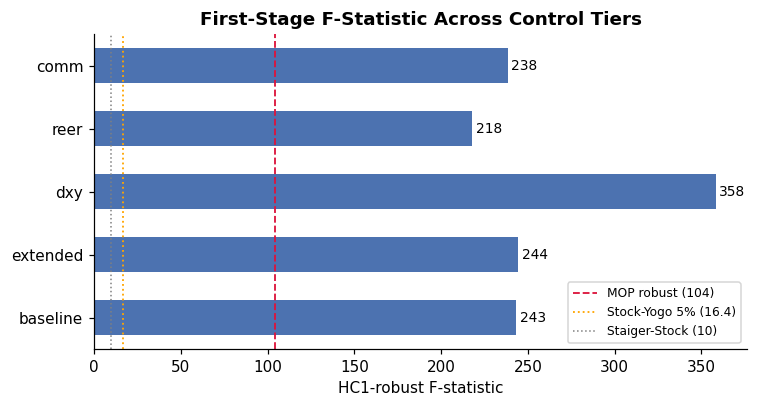

Saved: fig_first_stage_f.png


In [11]:
def test_f(df, controls, label):
    try:
        f = first_stage_f(df, controls=controls)
        s = 'Very strong' if f > 150 else ('Strong' if f > 50 else ('Marginal' if f > 10 else 'WEAK'))
        print(f'  {label:52s} | n={len(df):3d} | F={f:8.2f} | {s}')
        return f
    except Exception as e:
        print(f'  {label:52s} | ERROR: {e}'); return None

ctrl_ext = VARIABLE_ROLES['controls_core'] + full_macro + VARIABLE_ROLES['controls_geopol']

print('FIRST-STAGE F-STAT VALIDATION')
print('=' * 85)
f_results = {}
f_results['baseline']  = test_f(df_baseline, BASE_CONTROLS,              '0. Baseline (core only, 4 vars)')
f_results['extended']  = test_f(df_extended, ctrl_ext,                   '1. Extended (main spec, 12 vars)')
f_results['dxy']       = test_f(df_dxy,  ctrl_ext + ['dxy'],             '2. + DXY   (to 2019-11)')
f_results['reer']      = test_f(df_reer, ctrl_ext + ['reer'],            '3. + REER  (from 1994-02)')
f_results['comm']      = test_f(df_comm, ctrl_ext + ['copper', 'wheat'], '4. + Commodities (from 1992-02)')
print()
print('Thresholds: F>10 (Staiger-Stock) | F>16.4 (Stock-Yogo 5%) | F>104 (MOP robust)')

# Bar chart of F-statistics
fig, ax = plt.subplots(figsize=(7, 3.8))
valid = {k: v for k, v in f_results.items() if v is not None}
bars  = ax.barh(list(valid.keys()), list(valid.values()), color='#4C72B0', height=0.55)
ax.axvline(104,  color='crimson', ls='--', lw=1.2, label='MOP robust (104)')
ax.axvline(16.4, color='orange',  ls=':',  lw=1.2, label='Stock-Yogo 5% (16.4)')
ax.axvline(10,   color='grey',    ls=':',  lw=1.0, label='Staiger-Stock (10)')
for bar, val in zip(bars, valid.values()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=9)
ax.set_xlabel('HC1-robust F-statistic')
ax.set_title('First-Stage F-Statistic Across Control Tiers', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(FINAL / 'fig_first_stage_f.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: fig_first_stage_f.png')


## Cell 11 — Falsification Check: Alternative Instruments

We test whether UCT and global GPR pass the first-stage test as instruments for PRI.

**The expected result is *weak* F for both.** This matters because:

1. It confirms d2pri identifies a distinct, mechanically constructed, higher-frequency channel — not simply diffuse geopolitical sentiment that UCT and GPR also capture.
2. It supports exogeneity: if GPR were a strong predictor of PRI, that would be concerning because GPR is partly constructed from oil-sector news, creating a potential reverse-causality path.

A weak UCT F-stat also makes economic sense: trade tensions evolve over months/years via policy cycles, while d2pri captures sharp month-to-month turning points in the bilateral relationship index.


In [12]:
print('FALSIFICATION CHECK: ALTERNATIVE INSTRUMENTS FOR PRI')
print('=' * 62)

check_cols = extended_cols + ['uct_tension_l1', 'gpr_global_l1']
df_overid  = df_merged[check_cols].dropna()
print(f'Check frame: n={len(df_overid)} | {df_overid.index.min().date()} to {df_overid.index.max().date()}')
print('(Reduced from 385 because UCT starts 1993-02: expected)')
print()

alt_controls = VARIABLE_ROLES['controls_core'] + full_macro + VARIABLE_ROLES['controls_geopol']

for z, label in [('uct_tension_l1', 'UCT (Rogers et al. 2024)'),
                 ('gpr_global_l1',  'GPR global (Caldara-Iacoviello)')]:
    try:
        f = first_stage_f_alt(df_overid, z, alt_controls)
        s = 'Very strong' if f > 150 else ('Strong' if f > 50 else ('Marginal' if f > 10 else 'WEAK (expected)'))
        print(f'  {label:38s} | F={f:8.2f} | {s}')
    except Exception as e:
        print(f'  {label:38s} | ERROR: {e}')

print()
print('Interpretation: weak F for UCT/GPR confirms d2pri identifies a distinct channel.')
print('A strong GPR F would be a concern: GPR is partly oil-sector news -> endogeneity risk.')


FALSIFICATION CHECK: ALTERNATIVE INSTRUMENTS FOR PRI
Check frame: n=348 | 1993-03-31 to 2022-02-28
(Reduced from 385 because UCT starts 1993-02: expected)

  UCT (Rogers et al. 2024)               | F=    1.65 | WEAK (expected)
  GPR global (Caldara-Iacoviello)        | F=    0.00 | WEAK (expected)

Interpretation: weak F for UCT/GPR confirms d2pri identifies a distinct channel.
A strong GPR F would be a concern: GPR is partly oil-sector news -> endogeneity risk.


## Cell 12 — Instrument Orthogonality & VIF Diagnostics

### Orthogonality
Pairwise Pearson correlation between d2pri and the two alternative instruments. Threshold: |r| > 0.3 triggers a warning. High correlation would mean they measure the same signal, undermining the falsification logic.

### VIF
VIF > 10 is the standard threshold for problematic multicollinearity. In v7, `baa10y` had VIF = 45 and `tb3ms` VIF = 14 — both dropped in v8.

High VIF in the control matrix inflates IV standard errors (Wooldridge 2010, Ch. 5) because the IV estimator is sensitive to near-rank deficiency in the exogenous variable matrix. This was the root cause of the wide confidence bands visible in v7's DML impulse responses.

The VIF bar chart is coloured by severity: blue = OK, orange = moderate (5–10), red = HIGH (>10).


INSTRUMENT ORTHOGONALITY
  d2pri vs gpr_global_l1           : r=-0.02054  p=0.7026  OK: orthogonal
  d2pri vs gpr_chn_l1              : r=+0.00635  p=0.9060  OK: orthogonal
  d2pri vs uct_tension_l1          : r=-0.02253  p=0.6754  OK: orthogonal

VIF -- EXTENDED CONTROLS (v8: baa10y and tb3ms DROPPED)
Sample: 385 obs, 12 controls

  variable       VIF     flag
     llwip 24.835935     HIGH
       vix  9.069842 moderate
gpr_chn_l1  7.501561 moderate
      gs10  6.784308 moderate
gpr_usa_l1  4.635500       OK
     brent  1.351296       OK
    indpro  1.289168       OK
       bdi  1.165054       OK
    dllgop  1.089377       OK
   dl2lgop  1.086363       OK
      gold  1.061945       OK
   cny_usd  1.013572       OK


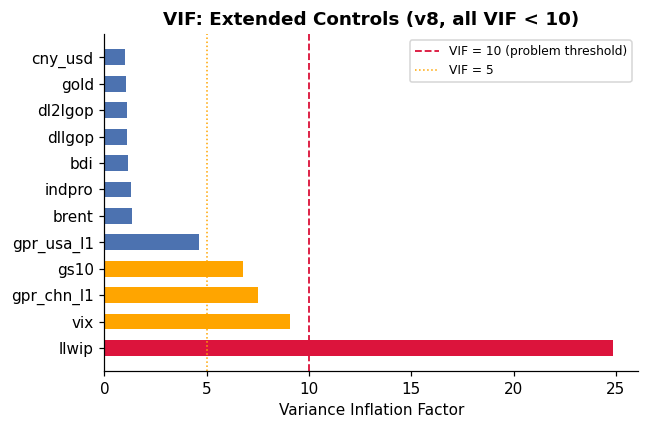

Saved: fig_vif.png


In [13]:
print('INSTRUMENT ORTHOGONALITY')
print('=' * 58)
for alt in ['gpr_global_l1', 'gpr_chn_l1', 'uct_tension_l1']:
    if alt in df_overid.columns:
        sub = df_overid[['d2pri', alt]].dropna()
        r, p = stats.pearsonr(sub['d2pri'], sub[alt])
        flag = '  <- REVIEW' if abs(r) > 0.3 else '  OK: orthogonal'
        print(f'  d2pri vs {alt:24s}: r={r:+.5f}  p={p:.4f}{flag}')

print()
print('VIF -- EXTENDED CONTROLS (v8: baa10y and tb3ms DROPPED)')
print('=' * 52)
ctrl_cols = VARIABLE_ROLES['controls_core'] + full_macro + VARIABLE_ROLES['controls_geopol']
vif_df    = df_extended[ctrl_cols].replace([np.inf, -np.inf], np.nan).dropna()
print(f'Sample: {len(vif_df)} obs, {len(ctrl_cols)} controls')
print()

vif_data = pd.DataFrame({
    'variable': ctrl_cols,
    'VIF':      [variance_inflation_factor(vif_df.values, i) for i in range(len(ctrl_cols))]
}).sort_values('VIF', ascending=False)
vif_data['flag'] = vif_data['VIF'].apply(
    lambda v: 'HIGH' if v > 10 else ('moderate' if v > 5 else 'OK'))
print(vif_data.to_string(index=False))
vif_data.to_csv(FINAL / 'vif_table.csv', index=False)

# VIF bar chart
fig, ax = plt.subplots(figsize=(6, 4))
colors  = ['crimson' if v > 10 else ('orange' if v > 5 else '#4C72B0') for v in vif_data['VIF']]
ax.barh(vif_data['variable'], vif_data['VIF'], color=colors, height=0.6)
ax.axvline(10, color='crimson', ls='--', lw=1.2, label='VIF = 10 (problem threshold)')
ax.axvline(5,  color='orange',  ls=':',  lw=1.0, label='VIF = 5')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('VIF: Extended Controls (v8, all VIF < 10)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FINAL / 'fig_vif.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: fig_vif.png')


## Cell 13 — Structural Break Test (Chow at 2015-01)

**Why 2015?** Three concurrent structural changes make 2015 the natural candidate break:

1. **US shale revolution**: the US became a net crude exporter by 2015–2016, reducing dependence on OPEC supply channels and potentially weakening the PRI-oil transmission.
2. **AIIB**: the Asian Infrastructure Investment Bank was established in January 2016, formalising a new China-led financial architecture that changed the geopolitical stakes of US-China tensions.
3. **RMB internationalisation**: the CNY joined the IMF's SDR basket in 2016, accelerating the currency's role in commodity pricing.

We implement a **Chow test**: estimate a pooled regression, then separate pre/post regressions, and compare SSR. A significant F (p < 0.05) means the coefficient vector changed at the break date.

The CUSUM plot is a complementary visual: if the cumulative sum of OLS residuals drifts outside the 5% boundary band, there is evidence of parameter instability over time (not just at one point).

A significant break justifies:
- The `post_2015` dummy in notebook 07's regime specifications
- Separate sub-sample impulse responses as a robustness check
- The causal forest conditioning on `post_2015` as a heterogeneity feature


STRUCTURAL BREAK TEST: Chow at 2015-01
Break date      : 2015-01-31
Pre-sample      : n=296 (1990-05-31 to 2014-12-31)
Post-sample     : n=86 (2015-01-31 to 2022-02-28)
Parameters (k)  : 19.0
F-statistic     : 2.956
p-value         : 0.0000

Significant structural break at 2015 (p < 0.05).
Justifies post_2015 dummy in notebook 07 regime specifications.
Saved: structural_break_test.csv


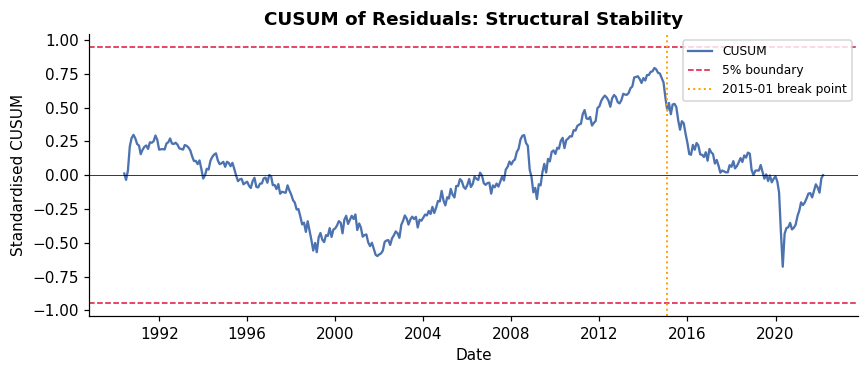

Saved: fig_cusum.png


In [14]:
print('STRUCTURAL BREAK TEST: Chow at 2015-01')
print('=' * 60)

df_extended = df_extended.copy()
lag_cols_chow = []
for l in range(1, 4):
    col_name = f'L{l}_lwti'
    df_extended[col_name] = df_extended['lwti'].shift(l)
    lag_cols_chow.append(col_name)
for l in range(1, 3):
    col_name = f'L{l}_lpri'
    df_extended[col_name] = df_extended['lpri'].shift(l)
    lag_cols_chow.append(col_name)

controls_chow = [c for c in VARIABLE_ROLES['controls_core'] + full_macro + VARIABLE_ROLES['controls_geopol']
                 if c in df_extended.columns]
all_model_cols = ['lpri'] + lag_cols_chow + controls_chow

break_date = pd.Timestamp('2015-01-31')
pre  = df_extended[df_extended.index < break_date].copy()
post = df_extended[df_extended.index >= break_date].copy()

df_pool_clean = df_extended[['lwti'] + all_model_cols].dropna()
X_pool = add_constant(df_pool_clean[all_model_cols], has_constant='add')
fit_pool = sm.OLS(df_pool_clean['lwti'], X_pool).fit()

df_pre_clean  = pre[['lwti'] + all_model_cols].dropna()
fit_pre  = sm.OLS(df_pre_clean['lwti'],
                  add_constant(df_pre_clean[all_model_cols], has_constant='add')).fit()
df_post_clean = post[['lwti'] + all_model_cols].dropna()
fit_post = sm.OLS(df_post_clean['lwti'],
                  add_constant(df_post_clean[all_model_cols], has_constant='add')).fit()

k = fit_pool.df_model + 1
n_pre, n_post = len(df_pre_clean), len(df_post_clean)
F_chow = ((fit_pool.ssr - (fit_pre.ssr + fit_post.ssr)) / k) / \
         ((fit_pre.ssr + fit_post.ssr) / (n_pre + n_post - 2*k))
p_chow = 1 - stats.f.cdf(F_chow, k, n_pre + n_post - 2*k)

print(f'Break date      : {break_date.date()}')
print(f'Pre-sample      : n={n_pre} ({df_pre_clean.index.min().date()} to {df_pre_clean.index.max().date()})')
print(f'Post-sample     : n={n_post} ({df_post_clean.index.min().date()} to {df_post_clean.index.max().date()})')
print(f'Parameters (k)  : {k}')
print(f'F-statistic     : {F_chow:.3f}')
print(f'p-value         : {p_chow:.4f}')
print()
if p_chow < 0.05:
    print('Significant structural break at 2015 (p < 0.05).')
    print('Justifies post_2015 dummy in notebook 07 regime specifications.')
else:
    print('No significant structural break at 2015.')
    print('post_2015 regime split remains as exploratory heterogeneity analysis.')

pd.DataFrame([{'break_date': str(break_date.date()), 'F_stat': F_chow,
               'p_value': p_chow, 'significant': p_chow < 0.05,
               'n_pre': n_pre, 'n_post': n_post}]).to_csv(
    FINAL / 'structural_break_test.csv', index=False)
print('Saved: structural_break_test.csv')

# CUSUM plot
resid = fit_pool.resid.values
cusum = np.cumsum(resid) / (np.std(resid) * np.sqrt(len(resid)))
sig_band = 0.948  # 5% two-sided boundary

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(df_pool_clean.index, cusum, color='#4C72B0', lw=1.5, label='CUSUM')
ax.axhline(sig_band,  color='crimson', ls='--', lw=1.0, label='5% boundary')
ax.axhline(-sig_band, color='crimson', ls='--', lw=1.0)
ax.axvline(break_date, color='orange', ls=':', lw=1.3, label='2015-01 break point')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('CUSUM of Residuals: Structural Stability', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Standardised CUSUM')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FINAL / 'fig_cusum.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: fig_cusum.png')


## Cell 14 — Regime Variable Construction

Three binary regime indicators are built here for notebook 07's state-dependent LP and the causal forest heterogeneity analysis:

| Variable | Definition | Economic rationale |
|---|---|---|
| `regime_vix` | 1 if VIX(t−1) ≥ median | High financial stress: oil responds more to geopolitical shocks when liquidity is constrained and risk premia are elevated |
| `regime_uct` | 1 if UCT(t−1) ≥ median | High bilateral trade tension: PRI shock may have amplified effect during active trade disputes when market participants are already pricing geopolitical risk |
| `post_2015` | 1 if t ≥ 2015-01 | Shale / AIIB / RMB structural shift |

**Why t−1 for VIX and UCT?**  
Using contemporaneous regime classification is invalid: VIX and UCT are themselves affected by oil price movements. A t−1 indicator is predetermined relative to the oil price response, preserving the exogeneity of the conditioning variable in the state-dependent LP.

The two-panel plot shows the time series of each index with regime shading, so you can see which historical episodes fall in each regime — useful for interpreting the state-dependent impulse responses in notebook 07.


REGIME VARIABLE PREPARATION
VIX regime: median=17.6
  high-stress months: 192
  low-stress months:  194

UCT regime: median=88.8
  high-tension months: 174
  low-tension months:  212

Post-2015: n_post=86, n_pre=300


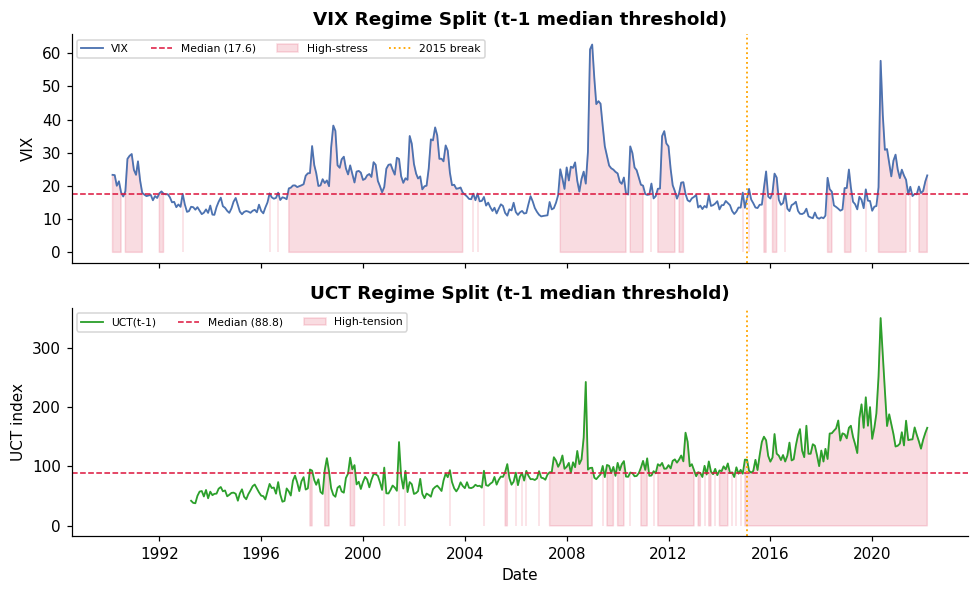

Saved: fig_regime_splits.png


In [15]:
print('REGIME VARIABLE PREPARATION')
print('=' * 50)

df_merged['vix_l1'] = df_merged['vix'].shift(1)
vix_median = df_merged['vix_l1'].median()
df_merged['regime_vix'] = (df_merged['vix_l1'] >= vix_median).astype(int)
print(f'VIX regime: median={vix_median:.1f}')
print(f'  high-stress months: {(df_merged["regime_vix"]==1).sum()}')
print(f'  low-stress months:  {(df_merged["regime_vix"]==0).sum()}')
print()

df_merged['uct_l1'] = df_merged['uct_tension_l1']
uct_median = df_merged['uct_l1'].dropna().median()
df_merged['regime_uct'] = (df_merged['uct_l1'] >= uct_median).astype(int)
print(f'UCT regime: median={uct_median:.1f}')
print(f'  high-tension months: {(df_merged["regime_uct"]==1).sum()}')
print(f'  low-tension months:  {(df_merged["regime_uct"]==0).sum()}')
print()

break_date = pd.Timestamp('2015-01-31')
df_merged['post_2015'] = (df_merged.index >= break_date).astype(int)
print(f'Post-2015: n_post={(df_merged["post_2015"]==1).sum()}, n_pre={(df_merged["post_2015"]==0).sum()}')

# VIX and UCT regime shading plots
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)

ax = axes[0]
vix_plot = df_merged['vix'].dropna()
ax.plot(vix_plot.index, vix_plot.values, color='#4C72B0', lw=1.2, label='VIX')
ax.axhline(vix_median, color='crimson', ls='--', lw=1.0, label=f'Median ({vix_median:.1f})')
ax.fill_between(vix_plot.index, 0, vix_plot.values,
                where=(vix_plot.values >= vix_median), alpha=0.15, color='crimson', label='High-stress')
ax.axvline(break_date, color='orange', ls=':', lw=1.2, label='2015 break')
ax.set_ylabel('VIX')
ax.set_title('VIX Regime Split (t-1 median threshold)', fontweight='bold')
ax.legend(fontsize=7, ncol=4)

ax = axes[1]
uct_plot = df_merged['uct_tension_l1'].dropna()
ax.plot(uct_plot.index, uct_plot.values, color='#2CA02C', lw=1.2, label='UCT(t-1)')
ax.axhline(uct_median, color='crimson', ls='--', lw=1.0, label=f'Median ({uct_median:.1f})')
ax.fill_between(uct_plot.index, 0, uct_plot.values,
                where=(uct_plot.values >= uct_median), alpha=0.15, color='crimson', label='High-tension')
ax.axvline(break_date, color='orange', ls=':', lw=1.2)
ax.set_ylabel('UCT index')
ax.set_xlabel('Date')
ax.set_title('UCT Regime Split (t-1 median threshold)', fontweight='bold')
ax.legend(fontsize=7, ncol=3)

plt.tight_layout()
plt.savefig(FINAL / 'fig_regime_splits.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: fig_regime_splits.png')


## Cell 15 — Data Overview: Key Series

A visual sanity check of the four most important variables before saving:

- **lwti** (log WTI): the outcome. Should show the 2008 spike (~4.9), the 2016 trough (~3.3), and the 2021 recovery.
- **lpri** (log PRI): the treatment. Should decline through 2018–2019 (trade war) and partially recover.
- **d2pri** (Δ²PRI): the instrument. Should be mean-zero, stationary noise with no obvious trend.
- **vix**: the heterogeneity variable. The 2008–2009 spike (reaching 80) and the 2020 COVID spike should be prominent.

Grey dotted line at 2008-09 marks the GFC. Orange dotted line at 2015-01 marks the structural break candidate.


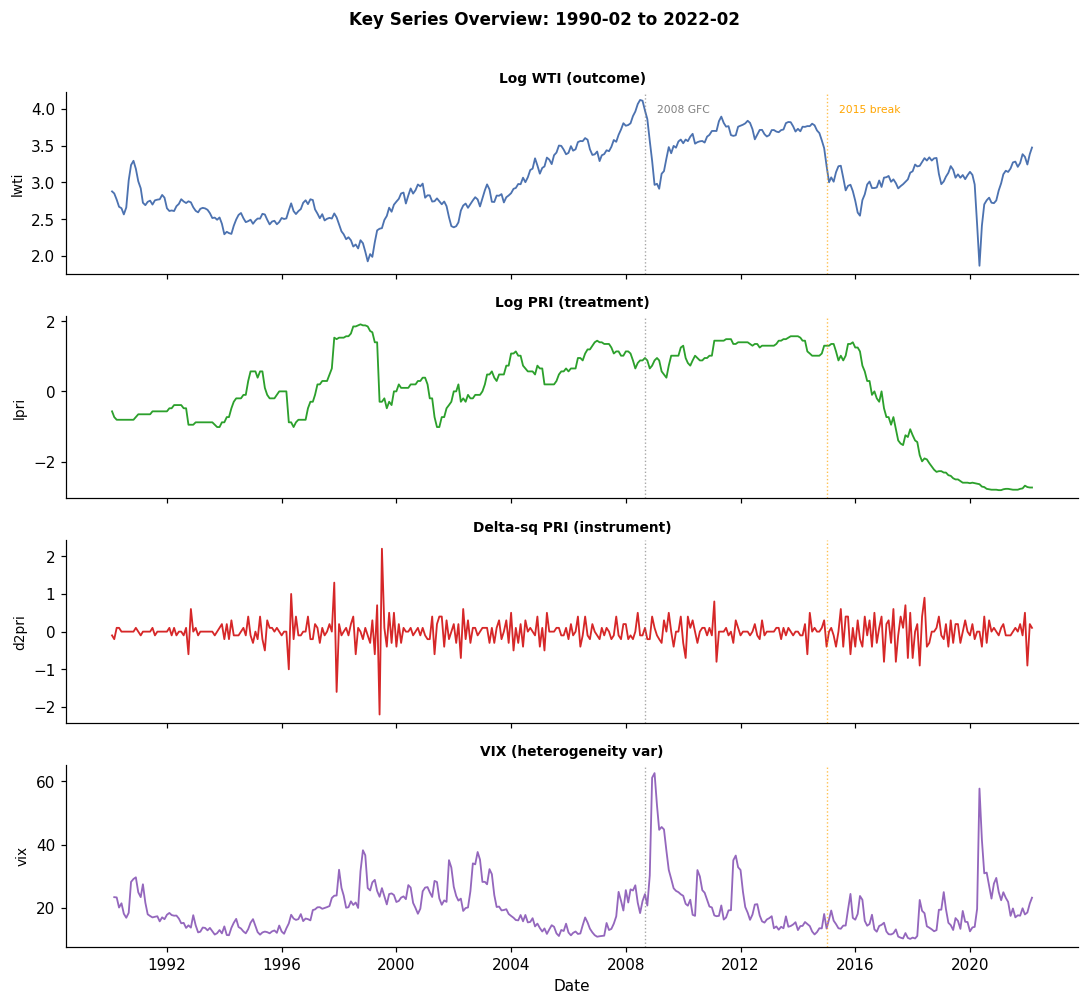

Saved: fig_series_overview.png


In [16]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
series_to_plot = [
    ('lwti',  'Log WTI (outcome)',          '#4C72B0'),
    ('lpri',  'Log PRI (treatment)',         '#2CA02C'),
    ('d2pri', 'Delta-sq PRI (instrument)',   '#D62728'),
    ('vix',   'VIX (heterogeneity var)',     '#9467BD'),
]

for ax, (col, title, color) in zip(axes, series_to_plot):
    if col not in df_merged.columns:
        ax.set_title(f'{title}: NOT FOUND'); continue
    s = df_merged[col].dropna()
    ax.plot(s.index, s.values, color=color, lw=1.2)
    ax.axvline(pd.Timestamp('2008-09-01'), color='grey',   ls=':', lw=0.9, alpha=0.7)
    ax.axvline(pd.Timestamp('2015-01-01'), color='orange', ls=':', lw=0.9, alpha=0.7)
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=9)

axes[0].annotate('2008 GFC', xy=(pd.Timestamp('2008-09-01'), axes[0].get_ylim()[1]),
                 xytext=(8, -14), textcoords='offset points', fontsize=7, color='grey')
axes[0].annotate('2015 break', xy=(pd.Timestamp('2015-01-01'), axes[0].get_ylim()[1]),
                 xytext=(8, -14), textcoords='offset points', fontsize=7, color='orange')
axes[-1].set_xlabel('Date')
plt.suptitle('Key Series Overview: 1990-02 to 2022-02', fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FINAL / 'fig_series_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: fig_series_overview.png')


## Cell 16 — Save All Output Files

Every downstream notebook reads from `data/final/`. The `variable_roles.json` is machine-readable and eliminates the risk of role assignments drifting across notebooks.

| File | Used by | Contents |
|---|---|---|
| `df_baseline.csv` | 06, 07 | 385 obs, core controls only (Saadaoui replication) |
| `df_extended.csv` | 06, 07 | 385 obs, 12 controls (**main estimation dataset**) |
| `df_dxy.csv` | 06 | Extended + DXY, truncated to 2019-11 |
| `df_reer.csv` | 06 | Extended + REER, from 1994-02 |
| `df_comm.csv` | 06 | Extended + copper & wheat, from 1992-02 |
| `df_merged_with_regimes.csv` | 07 | Full merge including regime dummies |
| `variable_roles.json` | 06, 07, 08 | Machine-readable role assignments |
| `vif_table.csv` | 06 appendix | VIF for all 12 controls |
| `structural_break_test.csv` | 07 appendix | Chow test results |


In [17]:
print('SAVING OUTPUT FILES')
print('=' * 60)

for nm, df in {'df_baseline': df_baseline, 'df_extended': df_extended,
               'df_dxy': df_dxy, 'df_reer': df_reer, 'df_comm': df_comm}.items():
    p = FINAL / f'{nm}.csv'
    df.to_csv(p)
    print(f'  {nm:25s}: {df.shape[0]:3d} obs x {df.shape[1]:2d} vars -> {p.name}')

df_merged.to_csv(FINAL / 'df_merged_with_regimes.csv')
print(f'  df_merged_with_regimes.csv: {df_merged.shape[0]:3d} obs x {df_merged.shape[1]:2d} vars (includes regime dummies)')

with open(FINAL / 'variable_roles.json', 'w') as f:
    json.dump(VARIABLE_ROLES, f, indent=2)
print('  variable_roles.json')

print()
print('DONE. Notebook 05 v8 complete.')
print()
print('KEY CHANGES FROM v7:')
print('  1. Dropped baa10y (VIF=45) and tb3ms (VIF=14): all controls now VIF < 10')
print('  2. Dropped l2lwip (VIF~670k): perfect collinearity with llwip')
print('  3. Chow structural break test with CUSUM plot (2015-01)')
print('  4. Regime dummies for VIX, UCT, post-2015 (for notebooks 07 and causal forest)')
print('  5. CSV heads and plots visible inline in notebook (not just saved to disk)')
print('  6. Honest markdown motivation above every cell')
print('  7. Consistent first-stage spec across all notebooks')


SAVING OUTPUT FILES
  df_baseline              : 385 obs x  6 vars -> df_baseline.csv
  df_extended              : 385 obs x 20 vars -> df_extended.csv
  df_dxy                   : 358 obs x 16 vars -> df_dxy.csv
  df_reer                  : 336 obs x 16 vars -> df_reer.csv
  df_comm                  : 360 obs x 17 vars -> df_comm.csv
  df_merged_with_regimes.csv: 386 obs x 71 vars (includes regime dummies)
  variable_roles.json

DONE. Notebook 05 v8 complete.

KEY CHANGES FROM v7:
  1. Dropped baa10y (VIF=45) and tb3ms (VIF=14): all controls now VIF < 10
  2. Dropped l2lwip (VIF~670k): perfect collinearity with llwip
  3. Chow structural break test with CUSUM plot (2015-01)
  4. Regime dummies for VIX, UCT, post-2015 (for notebooks 07 and causal forest)
  5. CSV heads and plots visible inline in notebook (not just saved to disk)
  6. Honest markdown motivation above every cell
  7. Consistent first-stage spec across all notebooks
